<a href="https://colab.research.google.com/github/Loopinlogix/image_classification/blob/main/image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
# Clone a public GitHub repository
# Replace with the URL of the repository you want to clone
!git clone https://github.com/Loopinlogix/image_classification.git

# Change directory into the cloned repository (replace 'colabtools' with your repo name)
%cd image_classification

# List the contents of the directory
!ls

Cloning into 'image_classification'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/image_classification
README.md


STEP 1: LOADING AND PREPROCESSING DATA
Dataset loaded: (1797, 64)
Training set: (1437, 64), Testing set: (360, 64)

STEP 2: DEFINING PARAMETER GRID
{'n_estimators': [50, 100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4]}

STEP 3: GRID SEARCH (this may take a moment...)
Fitting 3 folds for each of 81 candidates, totalling 243 fits

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9715

STEP 4: MODEL EVALUATION
Accuracy:  0.9611
Precision: 0.9620
Recall:    0.9611
F1-Score:  0.9609

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.9

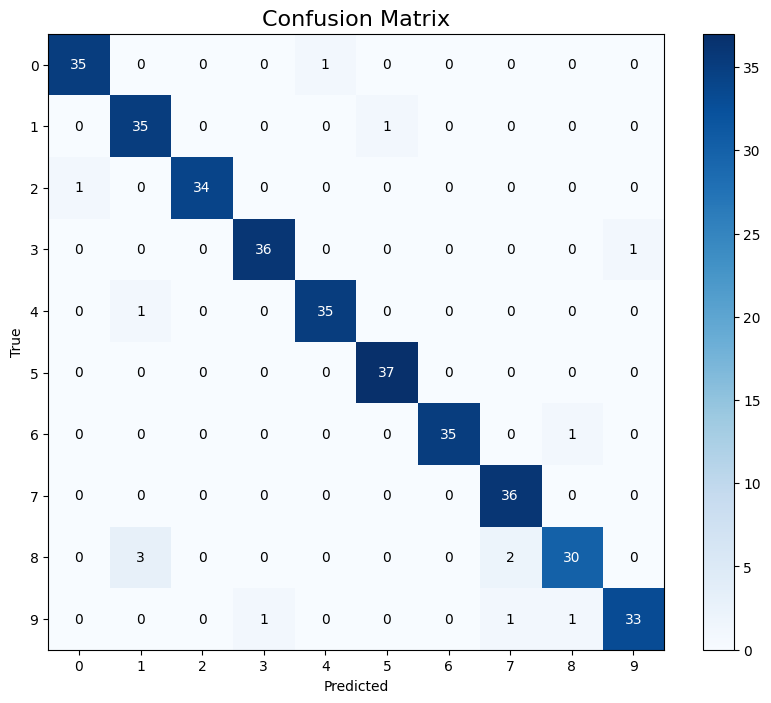


STEP 6: FEATURE IMPORTANCE


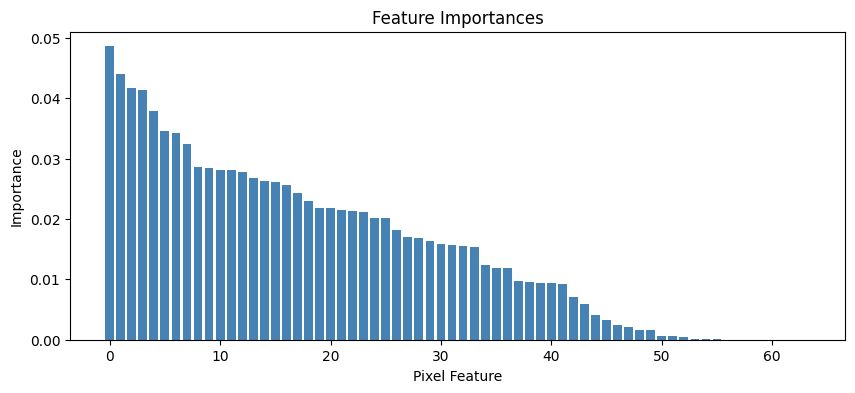

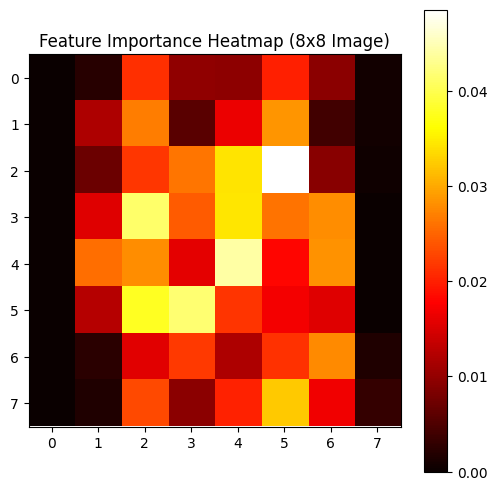

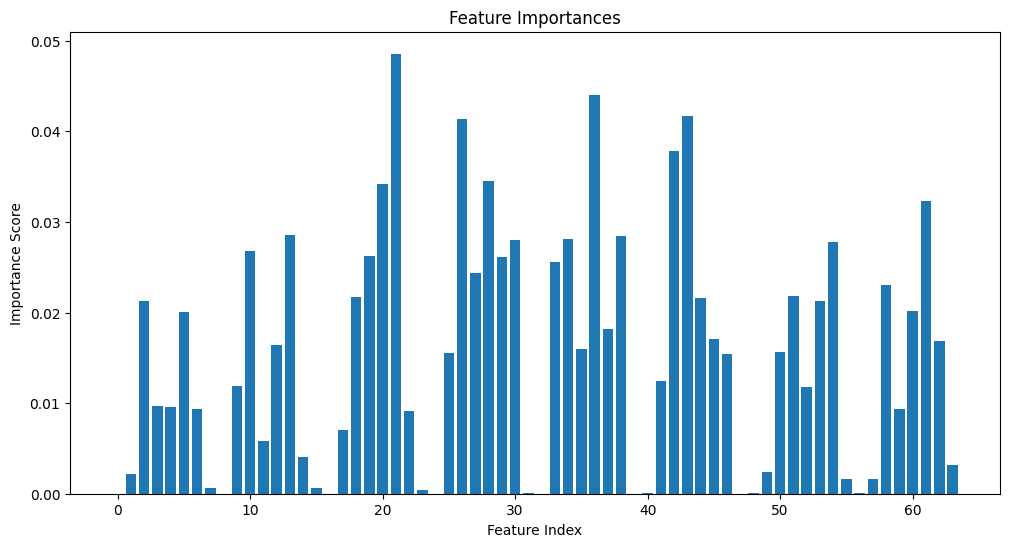


STEP 7: PREDICTION ON NEW IMAGES

Image 1:
  True Label: 5
  Predicted:  5
  Confidence: 0.5092
  Match: ✓

Image 2:
  True Label: 2
  Predicted:  2
  Confidence: 0.8990
  Match: ✓

Image 3:
  True Label: 8
  Predicted:  8
  Confidence: 0.5664
  Match: ✓

Image 4:
  True Label: 1
  Predicted:  1
  Confidence: 0.5788
  Match: ✓

Image 5:
  True Label: 7
  Predicted:  7
  Confidence: 0.6159
  Match: ✓

ASSIGNMENT COMPLETE!


In [7]:

#Image Classification with Random Forest


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
import warnings
warnings.filterwarnings('ignore')


# 1. LOAD AND PREPROCESS DATA
print("=" * 60)
print("STEP 1: LOADING AND PREPROCESSING DATA")
print("=" * 60)

digits = load_digits()
X = digits.data / 16.0  # Normalize to [0, 1]
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset loaded: {X.shape}")
print(f"Training set: {X_train.shape}, Testing set: {X_test.shape}")


# 2. DEFINE PARAMETER GRID

print("\n" + "=" * 60)
print("STEP 2: DEFINING PARAMETER GRID")
print("=" * 60)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
print(param_grid)


# 3. GRID SEARCH WITH RANDOM FOREST

print("\n" + "=" * 60)
print("STEP 3: GRID SEARCH (this may take a moment...)")
print("=" * 60)

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_


# 4. MODEL EVALUATION

print("\n" + "=" * 60)
print("STEP 4: MODEL EVALUATION")
print("=" * 60)

y_pred = best_model.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred, average='weighted'):.4f}")

print(f"\nClassification Report:\n{classification_report(y_test, y_pred)}")


# 5. CONFUSION MATRIX VISUALIZATION

print("\n" + "=" * 60)
print("STEP 5: CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix', fontsize=16)
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()


# 6. FEATURE IMPORTANCE

print("\n" + "=" * 60)
print("STEP 6: FEATURE IMPORTANCE")
print("=" * 60)

importances = best_model.feature_importances_

plt.figure(figsize=(10, 4))
plt.bar(range(64), np.sort(importances)[::-1], color='steelblue')
plt.title('Feature Importances')
plt.xlabel('Pixel Feature')
plt.ylabel('Importance')
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(importances.reshape(8, 8), cmap='hot')
plt.title('Feature Importance Heatmap (8x8 Image)')
plt.colorbar()
plt.show()

# Get feature importances from the best model
importances = best_model.feature_importances_

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importances")
plt.xlabel("Feature Index")
plt.ylabel("Importance Score")
plt.show()


# 7. PREDICTION FUNCTION

print("\n" + "=" * 60)
print("STEP 7: PREDICTION ON NEW IMAGES")
print("=" * 60)

def predict_new_image(image, model=best_model):
    """Predict class of a new image with same preprocessing."""
    img = np.array(image).flatten()
    img = img / 16.0  # Normalize
    img = img.reshape(1, -1)
    prediction = model.predict(img)[0]
    proba = model.predict_proba(img)[0]
    return prediction, proba

# Test on first 5 test images
for i in range(5):
    img_raw = X_test[i] * 16  # Back to original scale
    true = y_test[i]
    pred, probs = predict_new_image(img_raw)

    print(f"\nImage {i+1}:")
    print(f"  True Label: {true}")
    print(f"  Predicted:  {pred}")
    print(f"  Confidence: {probs[pred]:.4f}")
    print(f"  Match: {'✓' if pred == true else '✗'}")

print("\n" + "=" * 60)
print("ASSIGNMENT COMPLETE!")
print("=" * 60)

## Visualizing Original Images


STEP 8: VISUALIZING ORIGINAL IMAGES


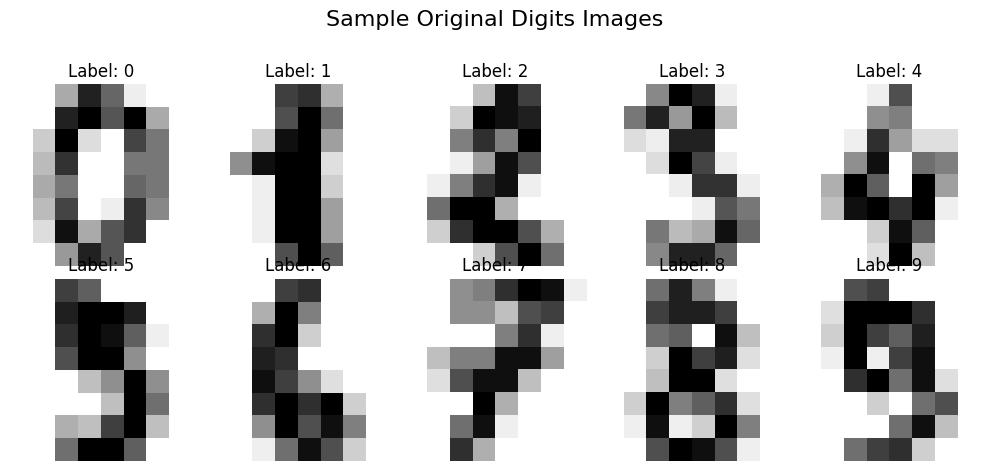

In [8]:
print("\n" + "=" * 60)
print("STEP 8: VISUALIZING ORIGINAL IMAGES")
print("=" * 60)

# Display some original images from the dataset
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(10, 5))
for ax, image, label in zip(axes.flatten(), digits.images, digits.target):
    ax.set_axis_off()
    ax.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'Label: {label}')
plt.suptitle('Sample Original Digits Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

## Visualizing Predictions on New Images


STEP 9: VISUALIZE PREDICTIONS ON NEW IMAGES


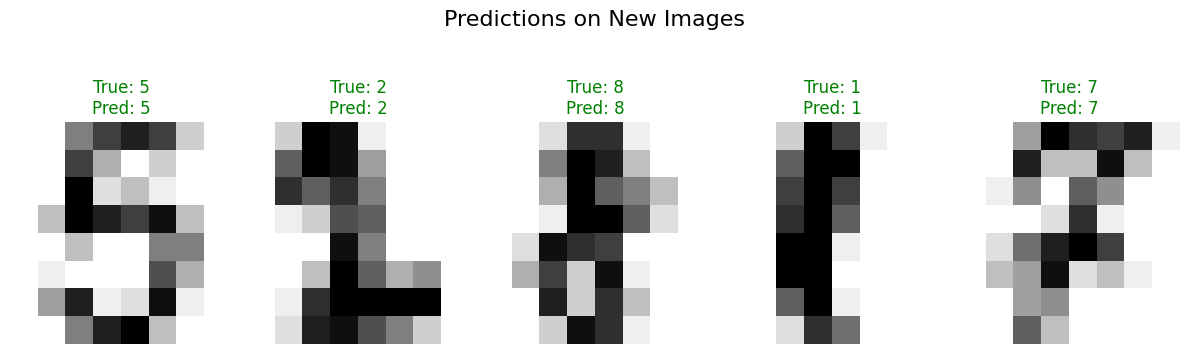

In [9]:
print("\n" + "=" * 60)
print("STEP 9: VISUALIZE PREDICTIONS ON NEW IMAGES")
print("=" * 60)

# Visualize some predictions
num_images_to_show = 5

fig, axes = plt.subplots(nrows=1, ncols=num_images_to_show, figsize=(12, 4))

for i in range(num_images_to_show):
    # Get a sample from the test set
    img_flat_normalized = X_test[i]
    img_raw = img_flat_normalized * 16 # Scale back to original pixel values for display
    true_label = y_test[i]

    # Predict using the previously defined function
    predicted_label, probabilities = predict_new_image(img_raw)

    # Reshape for display
    img_display = img_raw.reshape(8, 8)

    ax = axes[i]
    ax.imshow(img_display, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'True: {true_label}\nPred: {predicted_label}',
                 color='green' if predicted_label == true_label else 'red')
    ax.set_axis_off()

plt.suptitle('Predictions on New Images', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout
plt.show()

##Bonus

In [11]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("============================================================")
print("BONUS: SVM CLASSIFICATION")
print("============================================================")

# Create SVM model (RBF kernel is standard for image data)
svm_model = SVC(kernel='rbf', probability=True)

# Train SVM
svm_model.fit(X_train, y_train)

# Predict
svm_pred = svm_model.predict(X_test)

# Evaluation
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average='macro')
svm_recall = recall_score(y_test, svm_pred, average='macro')
svm_f1 = f1_score(y_test, svm_pred, average='macro')

print(f"SVM Accuracy:  {svm_accuracy:.4f}")
print(f"SVM Precision: {svm_precision:.4f}")
print(f"SVM Recall:    {svm_recall:.4f}")
print(f"SVM F1-Score:  {svm_f1:.4f}")

print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))

# Re-calculate Random Forest metrics since they were not stored in variables previously
rf_accuracy = accuracy_score(y_test, y_pred)
rf_precision = precision_score(y_test, y_pred, average='weighted')
rf_recall = recall_score(y_test, y_pred, average='weighted')
rf_f1 = f1_score(y_test, y_pred, average='weighted')

print("============================================================")
print("BONUS: MODEL COMPARISON (Random Forest vs SVM)")
print("============================================================")

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"SVM Accuracy:           {svm_accuracy:.4f}\n")

print(f"Random Forest F1:       {rf_f1:.4f}")
print(f"SVM F1:                 {svm_f1:.4f}\n")

if svm_accuracy > rf_accuracy:
    print("SVM performed better than Random Forest on accuracy.")
else:
    print("Random Forest performed better than SVM on accuracy.")

if svm_f1 > rf_f1:
    print("SVM performed better than Random Forest on F1-score.")
else:
    print("Random Forest performed better than SVM on F1-score.")

BONUS: SVM CLASSIFICATION
SVM Accuracy:  0.9917
SVM Precision: 0.9920
SVM Recall:    0.9915
SVM F1-Score:  0.9916

SVM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       1.00      1.00      1.00        36
           5       1.00      1.00      1.00        37
           6       1.00      1.00      1.00        36
           7       0.97      1.00      0.99        36
           8       1.00      0.94      0.97        35
           9       1.00      0.97      0.99        36

    accuracy                           0.99       360
   macro avg       0.99      0.99      0.99       360
weighted avg       0.99      0.99      0.99       360

BONUS: MODEL COMPARISON (Random Forest vs SVM)
Random Forest Accuracy: 0.9611
SVM Accuracy:        

### SVM Confusion Matrix Visualization


BONUS: SVM CONFUSION MATRIX


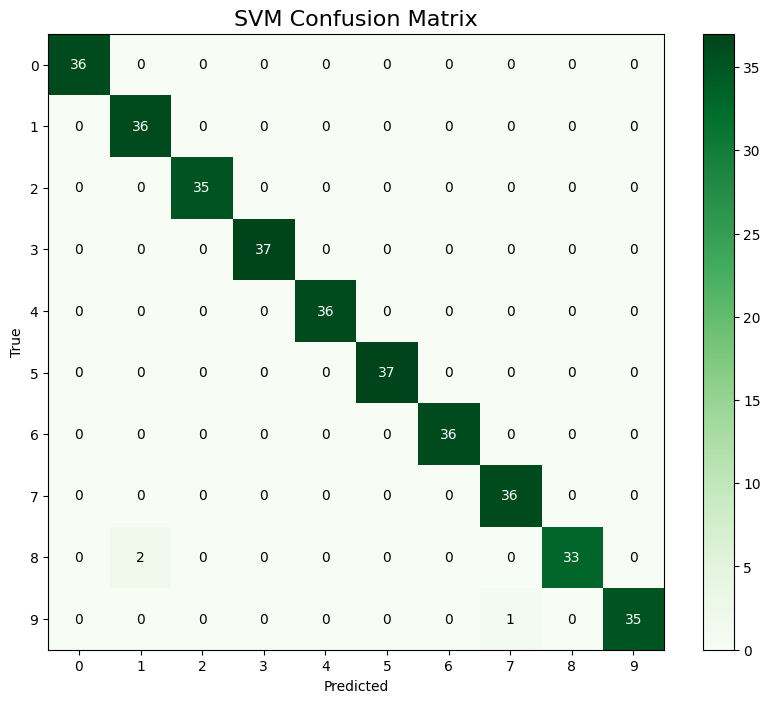

In [13]:
print("\n" + "=" * 60)
print("BONUS: SVM CONFUSION MATRIX")
print("=" * 60)

cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(10, 8))
plt.imshow(cm_svm, cmap='Greens') # Using a different cmap for distinction
plt.title('SVM Confusion Matrix', fontsize=16)
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm_svm[i, j], ha='center', va='center',
                color='white' if cm_svm[i, j] > cm_svm.max()/2 else 'black')

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

## Cloning a GitHub Repository

You can clone a GitHub repository directly into your Colab environment using the `!git clone` command. Replace the example URL with the URL of the repository you want to clone.

In [ ]:
# Change directory into the cloned repository (replace 'colabtools' with your repo name)
%cd colabtools

# List the contents of the directory
!ls